In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import json
import warnings

warnings.filterwarnings("ignore")

def parse_monthly_date(series):
    s = series.astype(str)
    parsed = pd.to_datetime(s, format="%Y-%m", errors="coerce")
    if parsed.isna().any():
        parsed_fallback = pd.to_datetime(s, errors="coerce")
        parsed = parsed.fillna(parsed_fallback)
    return parsed

def extract_coordinates(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        coords = geo_dict.get("coordinates")
        if isinstance(coords, list) and len(coords) >= 2:
            return coords[0], coords[1]
    except Exception:
        pass
    return None, None

df = pd.read_csv("Bangalore_2019_2024_RAW.csv")
df["date"] = parse_monthly_date(df["date"])

In [2]:
df = pd.read_csv("Bangalore_2019_2024_RAW.csv")
df["date"] = parse_monthly_date(df["date"])

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
if df["date"].notna().any():
    print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")

DATASET OVERVIEW
Shape: (46776, 26)
Columns: ['system:index', 'AOD', 'AtmosphericMoisture', 'BulkDensity', 'Clay', 'Copper', 'Elevation', 'Iron', 'LST', 'NDVI', 'NDWI', 'NO2', 'Nitrogen', 'Rain', 'SAVI', 'SO2', 'Sand', 'Slope', 'SoilMoisture', 'Temp', 'date', 'green_fraction', 'month', 'pH', 'year', '.geo']

Data types:
system:index                      str
AOD                           float64
AtmosphericMoisture           float64
BulkDensity                   float64
Clay                          float64
Copper                        float64
Elevation                       int64
Iron                          float64
LST                           float64
NDVI                          float64
NDWI                          float64
NO2                           float64
Nitrogen                      float64
Rain                          float64
SAVI                          float64
SO2                           float64
Sand                          float64
Slope                         fl

In [3]:
print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    "Data_Type": df.dtypes
})
missing = missing[missing["Missing_Count"] > 0].sort_values("Missing_Percentage", ascending=False)
print(missing)
if len(missing) == 0:
    print("No missing values found!")


MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage, Data_Type]
Index: []
No missing values found!


In [4]:
print("\n" + "=" * 80)
print("DUPLICATE ROWS")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage: {duplicates/len(df)*100:.2f}%")


DUPLICATE ROWS
Number of duplicate rows: 0


In [5]:
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

exclude_cols = ["system:index", "date", ".geo"]
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print(df[numerical_cols].describe().T)


STATISTICAL SUMMARY
                       count         mean        std          min  \
AOD                  46776.0     0.630320   0.206108     0.000000   
AtmosphericMoisture  46776.0    16.047350   3.184687     7.879718   
BulkDensity          46776.0     1.355159   0.018872     1.260000   
Clay                 46776.0    23.514416   3.029833    17.500000   
Copper               46776.0     0.568061   0.047084     0.449000   
Elevation            46776.0   870.264046  51.508184   699.000000   
Iron                 46776.0     1.175721   0.151492     0.875000   
LST                  46776.0    31.315099   4.012171     2.790000   
NDVI                 46776.0     0.189225   0.081856    -0.019721   
NDWI                 46776.0    -0.203875   0.093859    -0.653730   
NO2                  46776.0     0.000039   0.000016    -0.000002   
Nitrogen             46776.0    20.254026   3.596867    15.800000   
Rain                 46776.0    73.483429  79.468247     0.000000   
SAVI         

In [6]:
print("\n" + "=" * 80)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)

outlier_summary = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100

    outlier_summary.append({
        "Column": col,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": round(outlier_pct, 2),
        "Lower_Bound": round(lower_bound, 4),
        "Upper_Bound": round(upper_bound, 4),
        "Min_Value": round(df[col].min(), 4),
        "Max_Value": round(df[col].max(), 4)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df[outlier_df["Outlier_Count"] > 0].sort_values("Outlier_Percentage", ascending=False)
print(outlier_df)


OUTLIER DETECTION (IQR Method)
            Column  Outlier_Count  Outlier_Percentage  Lower_Bound  \
16           Slope           3193                6.83      -0.2055   
11        Nitrogen           2789                5.96      13.5500   
5        Elevation           2610                5.58     762.0000   
19  green_fraction           2241                4.79       0.4723   
21              pH           1289                2.76       6.2500   
2      BulkDensity           1218                2.60       1.3200   
12            Rain           1074                2.30    -166.7054   
10             NO2            944                2.02      -0.0000   
14             SO2            841                1.80      -0.0002   
8             NDVI            635                1.36      -0.0301   
13            SAVI            635                1.36      -0.0451   
0              AOD            368                0.79       0.0509   
3             Clay            119                0.25     

In [7]:
print("\n" + "=" * 80)
print("OUTLIER DETECTION (Z-Score Method, |z| > 3)")
print("=" * 80)

zscore_outliers = []
for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col], nan_policy="omit"))
    z_scores = np.nan_to_num(z_scores)
    outlier_count = (z_scores > 3).sum()
    outlier_pct = (outlier_count / len(df)) * 100
    zscore_outliers.append({
        "Column": col,
        "Outlier_Count": int(outlier_count),
        "Outlier_Percentage": round(outlier_pct, 2)
    })

zscore_df = pd.DataFrame(zscore_outliers)
zscore_df = zscore_df[zscore_df["Outlier_Count"] > 0].sort_values("Outlier_Percentage", ascending=False)
print(zscore_df)


OUTLIER DETECTION (Z-Score Method, |z| > 3)
            Column  Outlier_Count  Outlier_Percentage
16           Slope           1052                2.25
2      BulkDensity            861                1.84
12            Rain            801                1.71
11        Nitrogen            746                1.59
19  green_fraction            682                1.46
10             NO2            385                0.82
14             SO2            379                0.81
8             NDVI            267                0.57
13            SAVI            267                0.57
0              AOD            144                0.31
9             NDWI             72                0.15
5        Elevation             57                0.12
21              pH             56                0.12
7              LST              5                0.01


In [8]:
print("\n" + "=" * 80)
print("DATA QUALITY CHECKS")
print("=" * 80)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n1. LOW VARIANCE FEATURES:")
variance_check = []
for col in numerical_cols:
    unique_count = df[col].nunique(dropna=True)
    unique_ratio = unique_count / len(df)
    std_dev = df[col].std()
    if unique_ratio < 0.01:
        variance_check.append({
            "Column": col,
            "Unique_Count": unique_count,
            "Unique_Ratio": round(unique_ratio, 4),
            "Std_Dev": round(std_dev, 4)
        })
if variance_check:
    print(pd.DataFrame(variance_check))
else:
    print("No low variance features found.")

print("\n2. NEGATIVE VALUES CHECK (for features that should be positive):")
positive_features = ["AOD", "Rain", "Temp", "LST", "green_fraction", "BulkDensity",
                     "Clay", "Sand", "Copper", "Iron", "Nitrogen", "Elevation", "SoilMoisture"]
negative_values = []
for col in positive_features:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            negative_values.append({
                "Column": col,
                "Negative_Count": int(neg_count),
                "Negative_Percentage": round(neg_count/len(df)*100, 2),
                "Min_Value": round(df[col].min(), 4)
            })
if negative_values:
    print(pd.DataFrame(negative_values))
else:
    print("No unexpected negative values found.")

print("\n3. VALUE RANGE VALIDATION:")
range_checks = {
    "NDVI": (-1, 1),
    "NDWI": (-1, 1),
    "SAVI": (-1, 1),
    "pH": (0, 14),
    "green_fraction": (0, 1)
}
range_issues = []
for col, (min_val, max_val) in range_checks.items():
    if col in df.columns:
        out_of_range = df[(df[col] < min_val) | (df[col] > max_val)]
        if len(out_of_range) > 0:
            range_issues.append({
                "Column": col,
                "Expected_Range": f"[{min_val}, {max_val}]",
                "Out_of_Range_Count": len(out_of_range),
                "Actual_Min": round(df[col].min(), 4),
                "Actual_Max": round(df[col].max(), 4)
            })
if range_issues:
    print(pd.DataFrame(range_issues))
else:
    print("All checked features are within expected ranges.")

print("\n4. DATE PARSE CHECK:")
date_missing = df["date"].isna().sum()
print(f"Missing/invalid dates: {date_missing}")


DATA QUALITY CHECKS

1. LOW VARIANCE FEATURES:
        Column  Unique_Count  Unique_Ratio  Std_Dev
0  BulkDensity            14        0.0003   0.0189
1         Clay           129        0.0028   3.0298
2       Copper           187        0.0040   0.0471
3    Elevation           199        0.0043  51.5082
4         Iron           129        0.0028   0.1515
5     Nitrogen           128        0.0027   3.5969
6         Sand           187        0.0040   4.7084
7        month            70        0.0015  21.1594
8           pH             7        0.0001   0.0946
9         year             6        0.0001   1.7221

2. NEGATIVE VALUES CHECK (for features that should be positive):
No unexpected negative values found.

3. VALUE RANGE VALIDATION:
  Column Expected_Range  Out_of_Range_Count  Actual_Min  Actual_Max
0   SAVI        [-1, 1]                   5     -0.0296      1.1235

4. DATE PARSE CHECK:
Missing/invalid dates: 0


In [9]:
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

exclude_cols = ["system:index", "date", ".geo"]
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

corr_matrix = df[numerical_cols].corr()

print("\n1. HIGHLY CORRELATED FEATURES (|r| > 0.9):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr.append({
                "Feature_1": corr_matrix.columns[i],
                "Feature_2": corr_matrix.columns[j],
                "Correlation": round(corr_val, 4)
            })
if high_corr:
    print(pd.DataFrame(high_corr).sort_values("Correlation", ascending=False))
else:
    print("No highly correlated features found (|r| > 0.9).")



CORRELATION ANALYSIS

1. HIGHLY CORRELATED FEATURES (|r| > 0.9):
  Feature_1 Feature_2  Correlation
0      Clay      Iron       1.0000
1    Copper      Sand       1.0000
2      NDVI      SAVI       1.0000
3     month      year       0.9846


In [10]:
print("\n" + "=" * 80)
print("SPATIAL ANALYSIS")
print("=" * 80)

if "longitude" not in df.columns or "latitude" not in df.columns:
    coords = df[".geo"].apply(extract_coordinates)
    df["longitude"], df["latitude"] = zip(*coords)

print(f"Longitude range: [{df['longitude'].min():.6f}, {df['longitude'].max():.6f}]")
print(f"Latitude range: [{df['latitude'].min():.6f}, {df['latitude'].max():.6f}]")
print(f"Unique locations: {df[['longitude', 'latitude']].drop_duplicates().shape[0]}")

print("\n1. POTENTIAL SPATIAL OUTLIERS:")
lon_z = pd.Series(np.abs(stats.zscore(df["longitude"], nan_policy="omit")), index=df.index).fillna(0)
lat_z = pd.Series(np.abs(stats.zscore(df["latitude"], nan_policy="omit")), index=df.index).fillna(0)
spatial_outliers = df[(lon_z > 3) | (lat_z > 3)]
print(f"Locations with unusual coordinates: {len(spatial_outliers)}")


SPATIAL ANALYSIS
Longitude range: [77.329012, 77.809610]
Latitude range: [12.656678, 13.218125]
Unique locations: 805

1. POTENTIAL SPATIAL OUTLIERS:
Locations with unusual coordinates: 0


In [11]:
print("\n" + "=" * 80)
print("FEATURE-SPECIFIC INSIGHTS")
print("=" * 80)

soil_features = ["Clay", "Sand", "pH", "BulkDensity", "Nitrogen", "Copper", "Iron"]
available_soil = [f for f in soil_features if f in df.columns]
if available_soil:
    print("\n1. SOIL FEATURES:")
    print(df[available_soil].describe().T[["mean", "std", "min", "max"]])

climate_features = ["Rain", "Temp", "LST", "AtmosphericMoisture", "SoilMoisture"]
available_climate = [f for f in climate_features if f in df.columns]
if available_climate:
    print("\n2. CLIMATE FEATURES:")
    print(df[available_climate].describe().T[["mean", "std", "min", "max"]])

veg_indices = ["NDVI", "NDWI", "SAVI", "green_fraction"]
available_veg = [f for f in veg_indices if f in df.columns]
if available_veg:
    print("\n3. VEGETATION INDICES:")
    print(df[available_veg].describe().T[["mean", "std", "min", "max"]])

pollution_features = ["AOD", "NO2", "SO2"]
available_pollution = [f for f in pollution_features if f in df.columns]
if available_pollution:
    print("\n4. POLLUTION INDICATORS:")
    print(df[available_pollution].describe().T[["mean", "std", "min", "max"]])



FEATURE-SPECIFIC INSIGHTS

1. SOIL FEATURES:
                  mean       std     min     max
Clay         23.514416  3.029833  17.500  32.600
Sand         56.806146  4.708435  44.900  67.200
pH            6.482177  0.094606   6.200   6.800
BulkDensity   1.355159  0.018872   1.260   1.400
Nitrogen     20.254026  3.596867  15.800  50.100
Copper        0.568061  0.047084   0.449   0.672
Iron          1.175721  0.151492   0.875   1.630

2. CLIMATE FEATURES:
                          mean        std        min         max
Rain                 73.483429  79.468247   0.000000  403.165275
Temp                 23.513082   2.302738  19.461688   30.157012
LST                  31.315099   4.012171   2.790000   43.525000
AtmosphericMoisture  16.047350   3.184687   7.879718   20.928096
SoilMoisture          0.195471   0.072017   0.051457    0.390877

3. VEGETATION INDICES:
                    mean       std       min       max
NDVI            0.189225  0.081856 -0.019721  0.749091
NDWI           -

In [14]:
print("\n" + "=" * 80)
print("PREPROCESSING - CLEANING SETUP")
print("=" * 80)

features_to_drop = ["Iron", "Copper", "SAVI"]
df_cleaned = df.drop(columns=features_to_drop, errors="ignore").copy()

df_cleaned["date"] = parse_monthly_date(df_cleaned["date"])

if "longitude" not in df_cleaned.columns or "latitude" not in df_cleaned.columns:
    coords = df_cleaned[".geo"].apply(extract_coordinates)
    df_cleaned["longitude"], df_cleaned["latitude"] = zip(*coords)

print(f"Dropped: {[f for f in features_to_drop if f in df.columns]}")
print(f"New shape: {df_cleaned.shape}")



PREPROCESSING - CLEANING SETUP
Dropped: ['Iron', 'Copper', 'SAVI']
New shape: (46776, 25)


In [15]:
print("\n" + "=" * 80)
print("OUTLIER DETECTION & HANDLING")
print("=" * 80)

outlier_features = ["Nitrogen", "Slope", "Elevation", "pH", "AOD", "Rain"]
outlier_stats = []

for feature in outlier_features:
    if feature in df_cleaned.columns:
        Q1 = df_cleaned[feature].quantile(0.25)
        Q3 = df_cleaned[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_before = ((df_cleaned[feature] < lower_bound) | (df_cleaned[feature] > upper_bound)).sum()
        outlier_pct = (outliers_before / len(df_cleaned)) * 100

        df_cleaned[feature] = df_cleaned[feature].clip(lower=lower_bound, upper=upper_bound)

        outlier_stats.append({
            "Feature": feature,
            "Outliers_Capped": int(outliers_before),
            "Percentage": round(outlier_pct, 2),
            "Lower_Bound": round(lower_bound, 4),
            "Upper_Bound": round(upper_bound, 4)
        })

if outlier_stats:
    print(pd.DataFrame(outlier_stats))
else:
    print("No outlier features found for capping.")


OUTLIER DETECTION & HANDLING
     Feature  Outliers_Capped  Percentage  Lower_Bound  Upper_Bound
0   Nitrogen             2789        5.96      13.5500      25.9500
1      Slope             3193        6.83      -0.2055       2.0093
2  Elevation             2610        5.58     762.0000     994.0000
3         pH             1289        2.76       6.2500       6.6500
4        AOD              368        0.79       0.0509       1.1903
5       Rain             1074        2.30    -166.7054     298.3695


In [16]:
print("\n" + "=" * 80)
print("APPLYING TRANSFORMATIONS")
print("=" * 80)

def safe_log1p(series, scale=1.0):
    values = series.astype(float)
    min_val = np.nanmin(values)
    shift = -min_val + 1e-9 if min_val <= 0 else 0.0
    return np.log1p((values + shift) * scale), shift

skewed_features = ["Rain", "NO2", "Slope", "Nitrogen", "green_fraction", "AOD", "SO2"]
print("\nSkewness before transformation:")
for feat in skewed_features:
    if feat in df_cleaned.columns:
        print(f"  {feat}: {df_cleaned[feat].skew():.4f}")

df_cleaned["Rain_log"] = np.log1p(df_cleaned["Rain"].clip(lower=0))
df_cleaned["AOD_log"] = np.log1p(df_cleaned["AOD"].clip(lower=0))
df_cleaned["Slope_log"] = np.log1p(df_cleaned["Slope"].clip(lower=0))
df_cleaned["Nitrogen_log"] = np.log1p(df_cleaned["Nitrogen"].clip(lower=0))

df_cleaned["NO2_log"], no2_shift = safe_log1p(df_cleaned["NO2"], scale=1e6)
df_cleaned["SO2_log"], so2_shift = safe_log1p(df_cleaned["SO2"], scale=1e6)

df_cleaned["green_fraction_log"] = np.log1p(df_cleaned["green_fraction"].clip(lower=0))
df_cleaned["green_fraction_sqrt"] = np.sqrt(df_cleaned["green_fraction"].clip(lower=0))

from scipy.stats import boxcox
green_fraction_positive = df_cleaned["green_fraction"].clip(lower=0) + 1e-6
df_cleaned["green_fraction_boxcox"], gf_lambda = boxcox(green_fraction_positive)

transformations = {
    "log": abs(df_cleaned["green_fraction_log"].skew()),
    "sqrt": abs(df_cleaned["green_fraction_sqrt"].skew()),
    "boxcox": abs(df_cleaned["green_fraction_boxcox"].skew())
}
best_transform = min(transformations, key=transformations.get)
green_fraction_final = f"green_fraction_{best_transform}"

print("\nTransformation notes:")
print(f"  NO2_log shift applied: {no2_shift:.6e}")
print(f"  SO2_log shift applied: {so2_shift:.6e}")
print(f"  green_fraction Box-Cox lambda: {gf_lambda:.4f}")
print(f"  Best green_fraction transform: {green_fraction_final}")

print("\nSkewness after transformation:")
transformed_features = ["Rain_log", "NO2_log", "SO2_log", "Slope_log", "Nitrogen_log", "AOD_log", green_fraction_final]
for feat in transformed_features:
    if feat in df_cleaned.columns:
        print(f"  {feat}: {df_cleaned[feat].skew():.4f}")



APPLYING TRANSFORMATIONS

Skewness before transformation:
  Rain: 1.0747
  NO2: 0.8192
  Slope: 0.6973
  Nitrogen: 0.9618
  green_fraction: 1.8033
  AOD: 0.6627
  SO2: 0.1428

Transformation notes:
  NO2_log shift applied: 2.143599e-06
  SO2_log shift applied: 7.615081e-04
  green_fraction Box-Cox lambda: -6.9585
  Best green_fraction transform: green_fraction_boxcox

Skewness after transformation:
  Rain_log: -0.6887
  NO2_log: -0.2469
  SO2_log: -8.6665
  Slope_log: 0.1572
  Nitrogen_log: 0.7560
  AOD_log: 0.4040
  green_fraction_boxcox: -0.1006


In [17]:
print("\n" + "=" * 80)
print("FINAL DATA CLEANUP & TEMPORAL FEATURES")
print("=" * 80)

transformed_cols = ["Rain_log", "NO2_log", "SO2_log", "Slope_log", "Nitrogen_log",
                   "green_fraction_log", "green_fraction_sqrt", "green_fraction_boxcox", "AOD_log"]
issues_found = False

for col in transformed_cols:
    if col in df_cleaned.columns:
        nan_count = df_cleaned[col].isnull().sum()
        inf_count = np.isinf(df_cleaned[col]).sum()
        if nan_count > 0 or inf_count > 0:
            issues_found = True
            if nan_count > 0:
                median_val = df_cleaned[col].median()
                df_cleaned[col] = df_cleaned[col].fillna(median_val)
            if inf_count > 0:
                finite_max = df_cleaned[col][np.isfinite(df_cleaned[col])].max()
                df_cleaned[col] = df_cleaned[col].replace([np.inf, -np.inf], finite_max)

if not issues_found:
    print("All transformed features are clean (no NaN/Inf).")
else:
    print("Transformed feature issues fixed.")

df_cleaned["date"] = parse_monthly_date(df_cleaned["date"])
df_cleaned["Month_Actual"] = df_cleaned["date"].dt.month
df_cleaned["Year"] = df_cleaned["date"].dt.year
df_cleaned["Month_Sin"] = np.sin(2 * np.pi * df_cleaned["Month_Actual"] / 12)
df_cleaned["Month_Cos"] = np.cos(2 * np.pi * df_cleaned["Month_Actual"] / 12)

print("Temporal features created: Month_Actual, Year, Month_Sin, Month_Cos")



FINAL DATA CLEANUP & TEMPORAL FEATURES
All transformed features are clean (no NaN/Inf).
Temporal features created: Month_Actual, Year, Month_Sin, Month_Cos


In [18]:
print("\n" + "=" * 80)
print("DEFINING FEATURE SETS")
print("=" * 80)

core_features = [
    "Rain_log", "Temp", "LST", "SoilMoisture",
    "NDVI", green_fraction_final,
    "Clay", "Nitrogen_log", "pH", "BulkDensity",
    "Elevation", "Slope_log",
    "AOD_log", "NO2_log", "SO2",
    "Month_Sin", "Month_Cos",
    "longitude", "latitude"
]

core_features = [f for f in core_features if f in df_cleaned.columns]

print(f"Total features selected: {len(core_features)}")
print(core_features)

feature_groups = {
    "Climate": ["Rain_log", "Temp", "LST", "SoilMoisture"],
    "Vegetation": ["NDVI", green_fraction_final],
    "Soil": ["Clay", "Nitrogen_log", "pH", "BulkDensity"],
    "Topography": ["Elevation", "Slope_log"],
    "Pollution": ["AOD_log", "NO2_log", "SO2"],
    "Temporal": ["Month_Sin", "Month_Cos"],
    "Spatial": ["longitude", "latitude"]
}

print("\nFeature breakdown:")
for group, feats in feature_groups.items():
    available = [f for f in feats if f in core_features]
    print(f"  {group}: {len(available)} ({available})")



DEFINING FEATURE SETS
Total features selected: 19
['Rain_log', 'Temp', 'LST', 'SoilMoisture', 'NDVI', 'green_fraction_boxcox', 'Clay', 'Nitrogen_log', 'pH', 'BulkDensity', 'Elevation', 'Slope_log', 'AOD_log', 'NO2_log', 'SO2', 'Month_Sin', 'Month_Cos', 'longitude', 'latitude']

Feature breakdown:
  Climate: 4 (['Rain_log', 'Temp', 'LST', 'SoilMoisture'])
  Vegetation: 2 (['NDVI', 'green_fraction_boxcox'])
  Soil: 4 (['Clay', 'Nitrogen_log', 'pH', 'BulkDensity'])
  Topography: 2 (['Elevation', 'Slope_log'])
  Pollution: 3 (['AOD_log', 'NO2_log', 'SO2'])
  Temporal: 2 (['Month_Sin', 'Month_Cos'])
  Spatial: 2 (['longitude', 'latitude'])


In [19]:
print("\n" + "=" * 80)
print("FEATURE QUALITY & MULTICOLLINEARITY")
print("=" * 80)

missing_check = df_cleaned[core_features].isnull().sum()
if missing_check.sum() > 0:
    print("WARNING: Features with missing values:")
    print(missing_check[missing_check > 0])
else:
    print("No missing values in core feature set.")

infinite_check = np.isinf(df_cleaned[core_features].values).sum()
if infinite_check > 0:
    print(f"WARNING: {infinite_check} infinite values found in core features.")
else:
    print("No infinite values in core features.")

corr_matrix = df_cleaned[core_features].corr()
high_corr_threshold = 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > high_corr_threshold:
            high_corr_pairs.append({
                "Feature_1": corr_matrix.columns[i],
                "Feature_2": corr_matrix.columns[j],
                "Correlation": round(corr_val, 3)
            })

print(f"\nHigh correlations (|r| > {high_corr_threshold}):")
if high_corr_pairs:
    print(pd.DataFrame(high_corr_pairs).sort_values("Correlation", ascending=False))
else:
    print("None found.")

variance_analysis = pd.DataFrame({
    "Feature": core_features,
    "Variance": [df_cleaned[col].var() for col in core_features],
    "Std_Dev": [df_cleaned[col].std() for col in core_features],
    "CV": [df_cleaned[col].std() / abs(df_cleaned[col].mean()) if df_cleaned[col].mean() != 0 else 0 for col in core_features]
}).sort_values("CV", ascending=False)

print("\nFeatures by Coefficient of Variation (Std/Mean):")
print(variance_analysis)



FEATURE QUALITY & MULTICOLLINEARITY
No missing values in core feature set.
No infinite values in core features.

High correlations (|r| > 0.8):
None found.

Features by Coefficient of Variation (Std/Mean):
                  Feature      Variance    Std_Dev        CV
16              Month_Cos  4.984677e-01   0.706022  6.858543
15              Month_Sin  4.648517e-01   0.681800  4.219882
14                    SO2  1.084015e-08   0.000104  3.062645
0                Rain_log  3.362676e+00   1.833760  0.557873
4                    NDVI  6.700350e-03   0.081856  0.432585
3            SoilMoisture  5.186400e-03   0.072017  0.368427
11              Slope_log  5.526527e-02   0.235086  0.367398
12                AOD_log  1.494922e-02   0.122267  0.254261
5   green_fraction_boxcox  1.264532e+01   3.556026  0.236440
6                    Clay  9.179886e+00   3.029833  0.128850
2                     LST  1.609752e+01   4.012171  0.128123
13                NO2_log  1.523076e-01   0.390266  0.106155


In [20]:
print("\n" + "=" * 80)
print("TIME-BASED TRAIN/VAL/TEST SPLIT")
print("=" * 80)

df_sorted = df_cleaned.sort_values(["date", "longitude", "latitude"]).reset_index(drop=True)

years = sorted(df_sorted["Year"].dropna().unique())
train_mask = val_mask = test_mask = None

if len(years) >= 3:
    test_year = years[-1]
    val_year = years[-2]
    train_years = years[:-2]

    train_mask = df_sorted["Year"].isin(train_years)
    val_mask = df_sorted["Year"] == val_year
    test_mask = df_sorted["Year"] == test_year

    print(f"Train years: {train_years}")
    print(f"Validation year: {val_year}")
    print(f"Test year: {test_year}")
else:
    print("Insufficient distinct years for year-based split. Falling back to chronological split (70/15/15).")
    n_total = len(df_sorted)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    train_mask = df_sorted.index < n_train
    val_mask = (df_sorted.index >= n_train) & (df_sorted.index < n_train + n_val)
    test_mask = df_sorted.index >= n_train + n_val

X_train = df_sorted.loc[train_mask, core_features].copy()
X_val = df_sorted.loc[val_mask, core_features].copy()
X_test = df_sorted.loc[test_mask, core_features].copy()

train_metadata = df_sorted.loc[train_mask, ["date", "longitude", "latitude", "Year", "Month_Actual"]].copy()
val_metadata = df_sorted.loc[val_mask, ["date", "longitude", "latitude", "Year", "Month_Actual"]].copy()
test_metadata = df_sorted.loc[test_mask, ["date", "longitude", "latitude", "Year", "Month_Actual"]].copy()

print(f"\nTrain set:      {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")

print(f"\nTrain date range:      {train_metadata['date'].min()} to {train_metadata['date'].max()}")
print(f"Validation date range: {val_metadata['date'].min()} to {val_metadata['date'].max()}")
print(f"Test date range:       {test_metadata['date'].min()} to {test_metadata['date'].max()}")

total_samples = len(df_sorted)
train_pct = (X_train.shape[0] / total_samples) * 100
val_pct = (X_val.shape[0] / total_samples) * 100
test_pct = (X_test.shape[0] / total_samples) * 100
print(f"\nSplit percentages:")
print(f"  Train: {train_pct:.1f}%")
print(f"  Validation: {val_pct:.1f}%")
print(f"  Test: {test_pct:.1f}%")



TIME-BASED TRAIN/VAL/TEST SPLIT
Train years: [2019, 2020, 2021, 2022]
Validation year: 2023
Test year: 2024

Train set:      29,704 samples
Validation set: 8,248 samples
Test set:       8,824 samples

Train date range:      2019-01-01 00:00:00 to 2022-12-01 00:00:00
Validation date range: 2023-01-01 00:00:00 to 2023-12-01 00:00:00
Test date range:       2024-01-01 00:00:00 to 2024-12-01 00:00:00

Split percentages:
  Train: 63.5%
  Validation: 17.6%
  Test: 18.9%


In [21]:
print("\n" + "=" * 80)
print("PREPROCESSING SUMMARY")
print("=" * 80)

print(f"""
Data Shapes:
  - Original: {df.shape}
  - After cleaning: {df_cleaned.shape}
  - X_train: {X_train.shape}
  - X_val: {X_val.shape}
  - X_test: {X_test.shape}

Transformations Applied:
  - Dropped: { [f for f in features_to_drop if f in df.columns] }
  - Outliers capped (IQR): { [f for f in outlier_features if f in df_cleaned.columns] }
  - Log transforms: Rain_log, NO2_log, SO2_log, Slope_log, Nitrogen_log, AOD_log
  - green_fraction best transform: {green_fraction_final}
  - Cyclical encoding: Month_Sin, Month_Cos
  - Coordinates extracted: longitude, latitude

Features ({len(core_features)}):
  {core_features}

Available Objects:
  - df_cleaned, df_sorted
  - X_train, X_val, X_test
  - train_metadata, val_metadata, test_metadata
  - train_mask, val_mask, test_mask
  - core_features
""")


PREPROCESSING SUMMARY

Data Shapes:
  - Original: (46776, 28)
  - After cleaning: (46776, 38)
  - X_train: (29704, 19)
  - X_val: (8248, 19)
  - X_test: (8824, 19)

Transformations Applied:
  - Dropped: ['Iron', 'Copper', 'SAVI']
  - Outliers capped (IQR): ['Nitrogen', 'Slope', 'Elevation', 'pH', 'AOD', 'Rain']
  - Log transforms: Rain_log, NO2_log, SO2_log, Slope_log, Nitrogen_log, AOD_log
  - green_fraction best transform: green_fraction_boxcox
  - Cyclical encoding: Month_Sin, Month_Cos
  - Coordinates extracted: longitude, latitude

Features (19):
  ['Rain_log', 'Temp', 'LST', 'SoilMoisture', 'NDVI', 'green_fraction_boxcox', 'Clay', 'Nitrogen_log', 'pH', 'BulkDensity', 'Elevation', 'Slope_log', 'AOD_log', 'NO2_log', 'SO2', 'Month_Sin', 'Month_Cos', 'longitude', 'latitude']

Available Objects:
  - df_cleaned, df_sorted
  - X_train, X_val, X_test
  - train_metadata, val_metadata, test_metadata
  - train_mask, val_mask, test_mask
  - core_features




COMPOSITE FERTILITY INDEX - BASELINE MODEL

Component Weights:
  Nitrogen       : 0.40
  pH             : 0.25
  NDVI           : 0.15
  SoilMoisture   : 0.10
  Clay           : 0.10

Total weight: 1.00

Fertility Index Summary:
  Range: [0.274, 0.895]
  Mean: 0.520 +/- 0.107

Fertility Class Distribution (percent):
FertilityClass
Medium    81.74
Low        9.42
High       8.84
Name: proportion, dtype: float64

Component Correlations with FertilityIndex:
      Component  Weight  Correlation
0      Nitrogen    0.40     0.944578
1            pH    0.25    -0.149638
2          NDVI    0.15     0.159936
3  SoilMoisture    0.10     0.164014
4          Clay    0.10     0.362307

Creating visualizations...


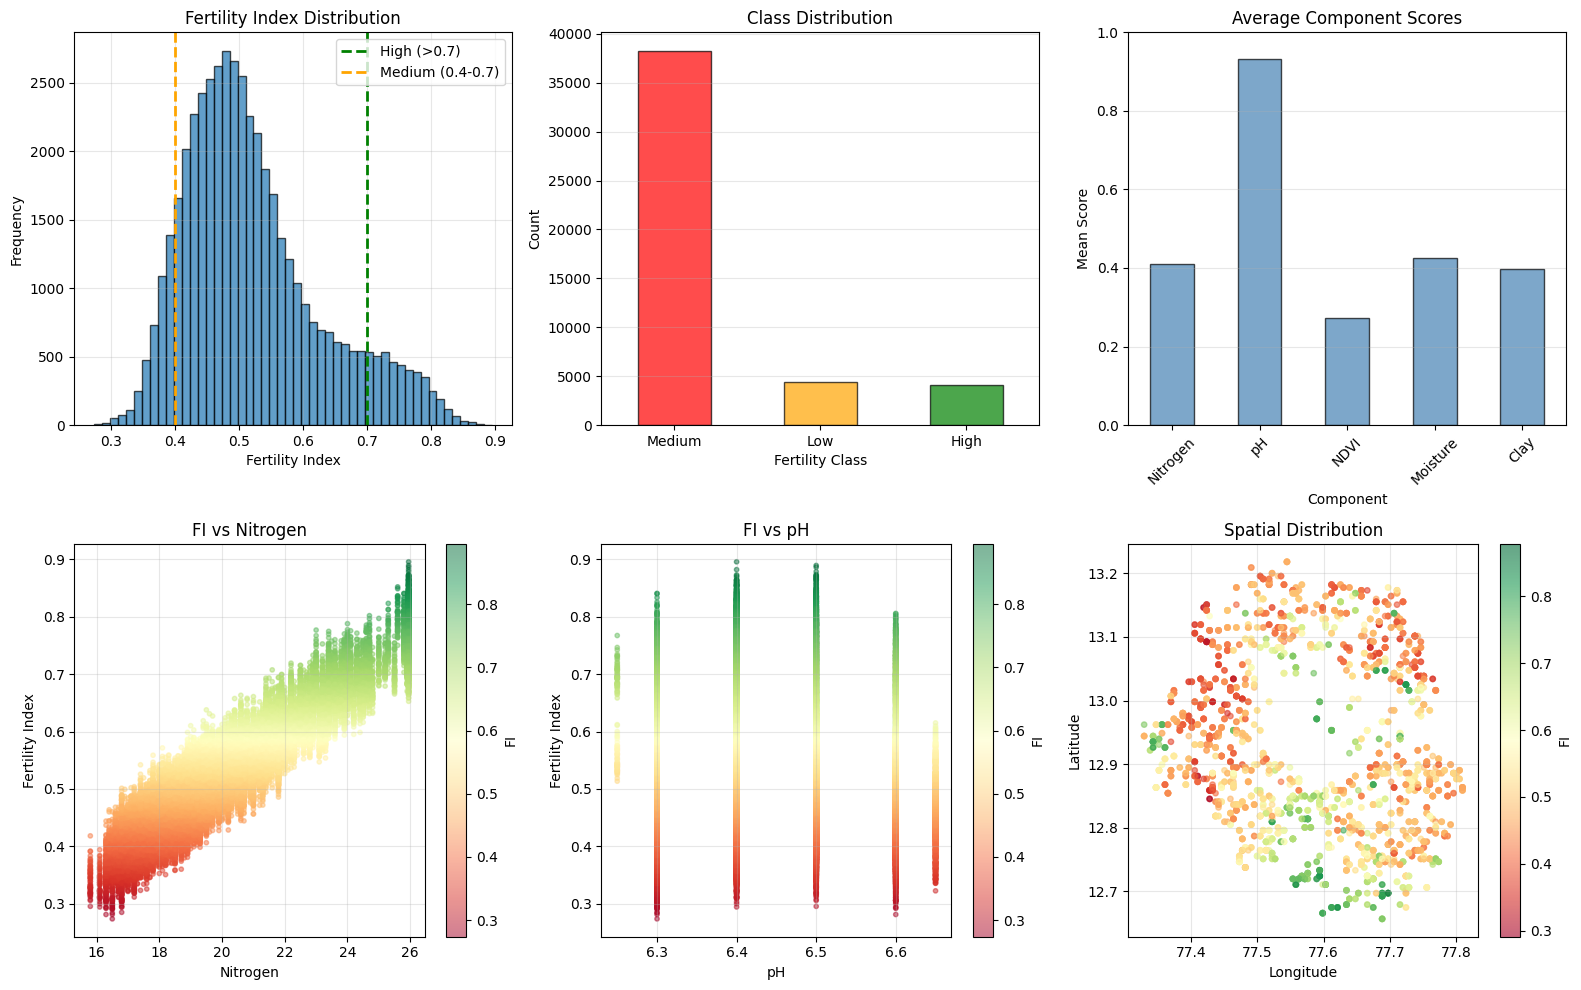


Targets prepared:
  y_train: 29704
  y_val:   8248
  y_test:  8824


In [22]:
print("\n" + "=" * 80)
print("COMPOSITE FERTILITY INDEX - BASELINE MODEL")
print("=" * 80)

required_components = ["Nitrogen", "pH", "NDVI", "SoilMoisture", "Clay"]
missing_components = [c for c in required_components if c not in df_sorted.columns]

if missing_components:
    print(f"Missing required components for fertility index: {missing_components}")
else:
    WEIGHTS = {
        "Nitrogen": 0.40,
        "pH": 0.25,
        "NDVI": 0.15,
        "SoilMoisture": 0.10,
        "Clay": 0.10
    }

    print("\nComponent Weights:")
    for component, weight in WEIGHTS.items():
        print(f"  {component:15s}: {weight:.2f}")
    print(f"\nTotal weight: {sum(WEIGHTS.values()):.2f}")

    def normalize_minmax(values):
        scaler = MinMaxScaler()
        return scaler.fit_transform(values.values.reshape(-1, 1)).flatten()

    def normalize_ph_optimal(ph_values, optimal=6.5, tolerance=1.0):
        deviation = np.abs(ph_values - optimal)
        scores = 1 - (deviation / tolerance)
        return np.clip(scores, 0, 1)

    df_fertility = df_sorted.copy()

    df_fertility["N_score"] = normalize_minmax(df_fertility["Nitrogen"])
    df_fertility["pH_score"] = normalize_ph_optimal(df_fertility["pH"])
    df_fertility["NDVI_score"] = normalize_minmax(df_fertility["NDVI"])
    df_fertility["Moisture_score"] = normalize_minmax(df_fertility["SoilMoisture"])
    df_fertility["Clay_score"] = normalize_minmax(df_fertility["Clay"])

    df_fertility["FertilityIndex"] = (
        WEIGHTS["Nitrogen"] * df_fertility["N_score"] +
        WEIGHTS["pH"] * df_fertility["pH_score"] +
        WEIGHTS["NDVI"] * df_fertility["NDVI_score"] +
        WEIGHTS["SoilMoisture"] * df_fertility["Moisture_score"] +
        WEIGHTS["Clay"] * df_fertility["Clay_score"]
    )

    def classify_fertility(fi_score):
        if fi_score >= 0.7:
            return "High"
        if fi_score >= 0.4:
            return "Medium"
        return "Low"

    df_fertility["FertilityClass"] = df_fertility["FertilityIndex"].apply(classify_fertility)

    print("\nFertility Index Summary:")
    print(f"  Range: [{df_fertility['FertilityIndex'].min():.3f}, {df_fertility['FertilityIndex'].max():.3f}]")
    print(f"  Mean: {df_fertility['FertilityIndex'].mean():.3f} +/- {df_fertility['FertilityIndex'].std():.3f}")

    print("\nFertility Class Distribution (percent):")
    print(df_fertility["FertilityClass"].value_counts(normalize=True).mul(100).round(2))

    print("\nComponent Correlations with FertilityIndex:")
    validation_rows = []
    for component in required_components:
        valid = df_fertility[[component, "FertilityIndex"]].dropna()
        if valid[component].nunique() <= 1:
            corr = np.nan
        else:
            corr = stats.pearsonr(valid[component], valid["FertilityIndex"])[0]
        validation_rows.append({
            "Component": component,
            "Weight": WEIGHTS[component],
            "Correlation": corr
        })
    validation_df = pd.DataFrame(validation_rows)
    print(validation_df)

    print("\nCreating visualizations...")
    fig = plt.figure(figsize=(16, 10))

    ax1 = plt.subplot(2, 3, 1)
    plt.hist(df_fertility["FertilityIndex"], bins=50, alpha=0.7, edgecolor="black")
    plt.axvline(0.7, color="green", linestyle="--", linewidth=2, label="High (>0.7)")
    plt.axvline(0.4, color="orange", linestyle="--", linewidth=2, label="Medium (0.4-0.7)")
    plt.xlabel("Fertility Index")
    plt.ylabel("Frequency")
    plt.title("Fertility Index Distribution")
    plt.legend()
    plt.grid(alpha=0.3)

    ax2 = plt.subplot(2, 3, 2)
    df_fertility["FertilityClass"].value_counts().plot(kind="bar", color=["red", "orange", "green"], alpha=0.7, edgecolor="black")
    plt.xlabel("Fertility Class")
    plt.ylabel("Count")
    plt.title("Class Distribution")
    plt.xticks(rotation=0)
    plt.grid(alpha=0.3, axis="y")

    ax3 = plt.subplot(2, 3, 3)
    score_cols = ["N_score", "pH_score", "NDVI_score", "Moisture_score", "Clay_score"]
    df_fertility[score_cols].mean().plot(kind="bar", color="steelblue", alpha=0.7, edgecolor="black")
    plt.xlabel("Component")
    plt.ylabel("Mean Score")
    plt.title("Average Component Scores")
    plt.xticks(range(5), ["Nitrogen", "pH", "NDVI", "Moisture", "Clay"], rotation=45)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3, axis="y")

    ax4 = plt.subplot(2, 3, 4)
    scatter = plt.scatter(df_fertility["Nitrogen"], df_fertility["FertilityIndex"],
                          c=df_fertility["FertilityIndex"], cmap="RdYlGn", alpha=0.5, s=10)
    plt.xlabel("Nitrogen")
    plt.ylabel("Fertility Index")
    plt.title("FI vs Nitrogen")
    plt.colorbar(scatter, label="FI")
    plt.grid(alpha=0.3)

    ax5 = plt.subplot(2, 3, 5)
    scatter = plt.scatter(df_fertility["pH"], df_fertility["FertilityIndex"],
                          c=df_fertility["FertilityIndex"], cmap="RdYlGn", alpha=0.5, s=10)
    plt.xlabel("pH")
    plt.ylabel("Fertility Index")
    plt.title("FI vs pH")
    plt.colorbar(scatter, label="FI")
    plt.grid(alpha=0.3)

    ax6 = plt.subplot(2, 3, 6)
    sample_size = min(3000, len(df_fertility))
    sample_idx = np.random.choice(len(df_fertility), sample_size, replace=False)
    scatter = plt.scatter(df_fertility.iloc[sample_idx]["longitude"],
                          df_fertility.iloc[sample_idx]["latitude"],
                          c=df_fertility.iloc[sample_idx]["FertilityIndex"],
                          cmap="RdYlGn", alpha=0.6, s=15)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Spatial Distribution")
    plt.colorbar(scatter, label="FI")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    y_train = df_fertility.loc[train_mask, "FertilityIndex"].values
    y_val = df_fertility.loc[val_mask, "FertilityIndex"].values
    y_test = df_fertility.loc[test_mask, "FertilityIndex"].values

    y_train_class = df_fertility.loc[train_mask, "FertilityClass"].values
    y_val_class = df_fertility.loc[val_mask, "FertilityClass"].values
    y_test_class = df_fertility.loc[test_mask, "FertilityClass"].values

    print("\nTargets prepared:")
    print(f"  y_train: {len(y_train)}")
    print(f"  y_val:   {len(y_val)}")
    print(f"  y_test:  {len(y_test)}")